# How does the Temperature affect DVA

In [ ]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustness')[0], "EV_DVA_Robustness"))
from src.config_base import GeneralConfig

ModuleNotFoundError: No module named 'src'

In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [3]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

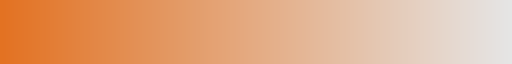

In [4]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 3))
tum_orange_cmap

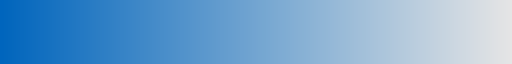

In [5]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

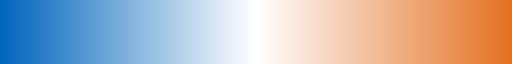

In [6]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=1)
colors = tum_cmap(np.linspace(1,0, 2))
tum_cmap

In [7]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [8]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [9]:
read_feather = ReadFeather()
#read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)
#read_feather.set_filter_I(filter_func_preprocess_Q)

## Temp Data

In [10]:
%%capture
df_vw_288_hot = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
#df_vw_288_hot = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_cold = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17_outside.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [11]:
df_vw_288_hot.P.mean()

3747.548652125258

In [12]:
df_vw_288_cold.P.mean()

3849.2997876378604

In [13]:
6*230*3

4140

In [14]:
%%capture
df_tesla_hot = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_5A_C17_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_cold = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE16_C13_outside_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 

In [15]:
8*400

3200

In [16]:
df_tesla_hot.P.mean()

3198.058803803927

In [17]:
df_tesla_cold.P.mean()

3918.1125867901387

In [18]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [19]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [20]:
dva_vw_288_hot, cap_vw_288_hot =dva_extractor.get_dva(time=df_vw_288_hot["time_h"], capacity=df_vw_288_hot["Q"], voltage=filter_func_preprocess_U(df_vw_288_hot["U"]),crop_cap_Ah=(1,180))
dva_vw_288_cold, cap_vw_288_cold =dva_extractor.get_dva(time=df_vw_288_cold["time_h"], capacity=df_vw_288_cold["Q"], voltage=filter_func_preprocess_U(df_vw_288_cold["U"]),crop_cap_Ah=(2,180))

In [21]:
dva_tesla_hot, cap_tesla_hot =dva_extractor.get_dva(time=df_tesla_hot["time_h"], capacity=df_tesla_hot["Q"], voltage=filter_func_preprocess_U(df_tesla_hot["U"]),crop_cap_Ah=(0,180))
dva_tesla_cold, cap_tesla_cold =dva_extractor.get_dva(time=df_tesla_cold["time_h"], capacity=df_tesla_cold["Q"], voltage=filter_func_preprocess_U(df_tesla_cold["U"]),crop_cap_Ah=(0,180))

## Plot

In [22]:
def plot_current_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        curr_filt = FilterMethods().rolling_mean_df(lst_dfs[ind].I,window_size=FilterMethods().round_to_next_odd_number(len(lst_dfs[ind].I)*0.1/100))
        axes.plot(lst_dfs[ind].time_h,curr_filt,color=colors[ind],linewidth=1.5)
    
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,16])
    tick_positions = np.array([0,8,16])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,12])
    tick_positions = np.array([0,4,8,12])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    return axes

In [23]:
def plot_current_tesla(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].time_h-1,lst_dfs[ind].I,color=colors[ind],linewidth=1.5) #shift for better comparability vw/Tesla and visibility
        
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,16])
    tick_positions = np.array([0,8,16])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,12])
    tick_positions = np.array([0,4,8,12])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    
    return axes

In [24]:
def plot_temp_vw(axes, lst_dfs = []):
    
    every = 10
    for ind,data in enumerate(lst_dfs):
        ambient =  FilterMethods().rolling_mean_df(lst_dfs[ind]["ambient_air_temp"],window_size=FilterMethods().round_to_next_odd_number(len(lst_dfs[ind]["ambient_air_temp"])*0.1/100))
        axes.plot(lst_dfs[ind].time_h[::every],ambient[::every]+1,color=colors[ind],linewidth=2,linestyle=":")#+1 for better visibility

    for ind,data in enumerate(lst_dfs):
        temp_cols = [col for col in lst_dfs[ind].columns if "pack_temp" in col]
        lst_dfs[ind]["T_max"] = lst_dfs[ind][temp_cols].max(axis=1)
        lst_dfs[ind]["T_min"] = lst_dfs[ind][temp_cols].min(axis=1)
        axes.fill_between(lst_dfs[ind].time_h, lst_dfs[ind].T_max,lst_dfs[ind].T_min,color=colors[ind],edgecolor="none",alpha=0.8,zorder=2)
    
    axes.set_ylabel(r"Temp. in °C",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,16])
    tick_positions = np.array([0,8,16])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,35])
    tick_positions = np.array([0,10,20,30,35])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    #axes.yaxis.set_label_coords(-0.13,0.5)
    return axes

In [25]:
def plot_temp_tesla(axes, lst_dfs = [], lst_dfs_ambient_temp = []):
    every = 10
    for ind,data in enumerate(lst_dfs_ambient_temp):
        ambient =  FilterMethods().rolling_mean_df(lst_dfs_ambient_temp[ind]["ambient_air_temp"],window_size=FilterMethods().round_to_next_odd_number(len(lst_dfs_ambient_temp[ind]["ambient_air_temp"])*1/100))
        axes.plot(lst_dfs_ambient_temp[ind].time_h[::every],ambient[::every]+1,color=colors[ind],linewidth=2,linestyle=":") #+1 for better visibility

    for ind,data in enumerate(lst_dfs):
        axes.fill_between(lst_dfs[ind].time_h, lst_dfs[ind].pack_temp_max,lst_dfs[ind].pack_temp_min,color=colors[ind],edgecolor="none",alpha=0.8,zorder=2)
        #axes.plot(lst_dfs_ambient_temp[ind].time_h,lst_dfs_ambient_temp[ind]["T"],color=colors[ind],linewidth=1.5,linestyle="--")
    
    axes.set_ylabel(r"Temp. in °C",fontsize=9)
    axes.set_xlabel(r"Charging time in h",fontsize=9)
    axes.set_xlim([0,16])
    tick_positions = np.array([0,8,16])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,35])
    tick_positions = np.array([0,10,20,30,35])
    axes.set_yticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([4,12]))
    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    #axes.yaxis.set_label_coords(-0.13,0.5)
    return axes

In [26]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [27]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [28]:
E_nom_VW = 58
E_nom_TM3 = 52.5

In [29]:
def plot_pOCV_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].U,color=colors[ind],linewidth=1.5)
    
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([370,450])
    tick_positions = np.array([370,390,410,430,450])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy in kWh",fontsize=9) 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])

    #insert axes right
    axins = axes.inset_axes([1, 412,28,36],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1],y1=np.hstack(np.array([df_vw_288_hot.E.max(),df_vw_288_cold.E.max()])/E_nom_VW*100))
    
    return axes

In [30]:
def plot_pOCV_tesla(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].U,color=colors[ind],linewidth=1.5)
        
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([0,156])
    tick_positions = np.array([0,30,60,90,120,156])
    axes.set_xticks(tick_positions)
    axes.set_ylim([340,380])
    tick_positions = np.array([340,350,360,370,380])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy in kWh",fontsize=9)   
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,30,60,90,120,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])

    #insert axes right
    axins = axes.inset_axes([1, 361, 28,18],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1],y1=np.array([df_tesla_hot.E.max(),df_tesla_cold.E.max()])/E_nom_TM3*100)
    return axes

In [31]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva):
    
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        #xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        #axes.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)

    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    axes.annotate(text='A', xy=(10,77), xytext=(18,56),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    #insert axes left
    axins = axes.inset_axes([35, 66,32,80],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axins.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)
    
    # subregion of the original image
    x1, x2, y1, y2 = 76, 90, 95, 150
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='B', xy=(76.5,136), xytext=(76.5,136),fontsize=9)


    #insert axes right
    axins = axes.inset_axes([95, 5,40,80],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
    xcap, yDVA = find_H2_peak(cap = lst_cap[0],dva = lst_dva[0]*Q_nom,Q_min=115,Q_max=145)
    maxDVA = np.argmax(yDVA)
    axins.scatter(xcap[maxDVA],yDVA[maxDVA],marker="o",color=colors[0],edgecolors="k",zorder=3)

    xpos, ypos = find_max_min(lst_cap[1], lst_dva[1]*Q_nom, xmin=115, xmax=145, maximum=True)
    axins.scatter(xpos,ypos,marker="o",color=colors[1],edgecolors="k",zorder=3)
   
    # subregion of the original image
    x1, x2, y1, y2 = 112, 145, 105, 135
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    # axins.annotate(text='', xy=(87,142), xytext=(87,98),fontsize=9,verticalalignment="bottom",
    #                   arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axins.annotate(text='C', xy=(114,127), xytext=(114,127),fontsize=9)
    
   
    # axes.annotate(text='A', xy=(12,77), xytext=(20,56),fontsize=9,
    #                   arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))
    # #insert axes left
    # axins = axes.inset_axes([33, 70,35,85],transform = axes.transData) # [x0, y0, width, height]

    # for ind,data in enumerate(lst_cap):
    #     axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=orange_colors[ind], linewidth=1.5,zorder=1)
    #     xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=0, xmax=15, maximum=False)
    #     axins.scatter(xpos,ypos,marker="o",color=orange_colors[ind],edgecolors="k",zorder=2)
        
    # # subregion of the original image
    # x1, x2, y1, y2 = 2, 15, 70, 110
    # axins.set_xlim(x1, x2)
    # axins.set_ylim(y1, y2)
    # axins.set_xticklabels([])
    # axins.set_yticklabels([])
    # axes.indicate_inset_zoom(axins, edgecolor="black")
    # axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    # axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    # #insert axes right
    # axins = axes.inset_axes([95, 5,35,85],transform = axes.transData) # [x0, y0, width, height]
    
    
    # for ind,data in enumerate(lst_cap):
    #     axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=orange_colors[ind], linewidth=1.5)
    #     xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
    #     axins.scatter(xpos,ypos,marker="d",color=orange_colors[ind],edgecolors="k",zorder=2)
    # # outlier
    # xpos, ypos = find_max_min(lst_cap[1], lst_dva[1]*Q_nom, xmin=78, xmax=104, maximum=True)
    # axins.scatter(xpos,ypos,marker="d",color=orange_colors[ind],edgecolors="gray",zorder=2,)
    # # subregion of the original image
    # x1, x2, y1, y2 = 76, 90, 95, 150
    # axins.set_xlim(x1, x2)
    # axins.set_ylim(y1, y2)
    # axins.set_xticklabels([])
    # axins.set_yticklabels([])
    # axes.indicate_inset_zoom(axins, edgecolor="black")
    # axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    # axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)

    # axins.annotate(text='', xy=(87,142), xytext=(87,98),fontsize=9,verticalalignment="bottom",
    #                   arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    # axins.annotate(text='B', xy=(76.5,138), xytext=(76.5,138),fontsize=9)
    return axes

In [32]:
def remove_outlier_IQR(signal,percentiles = [5,95]):
    Q1, Q3 = np.percentile(signal, percentiles)
    IQR = Q3 - Q1
    ul = Q3 + 1.5 * IQR
    ll = Q1 - 1.5 * IQR
    outliers = (signal > ul) | (signal < ll)
    return outliers

In [33]:
def plot_IR_vw(axes, lst_dfs = [],remove_outliers=True,percentiles = [5,95]):
    
    df1 = lst_dfs[0] # hot
    df2 = lst_dfs[1] # cold
    df_merge = pd.merge_asof(left = df1, right = df2, on='Q', suffixes=('_left', '_right'))
    curr_filt1 = FilterMethods().rolling_mean_df(df_merge.I_left,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_left)*1/100)).values[:,0]
    curr_filt2 = FilterMethods().rolling_mean_df(df_merge.I_right,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_right)*1/100)).values[:,0]
    resistance = np.abs((df_merge.U_left-df_merge.U_right)/np.mean(curr_filt1))*1000 # the currents are almost identical curr_filt1-curr_filt2 leads to high errors, due to values near 0
    if remove_outliers:
        outliers = remove_outlier_IQR(resistance,percentiles =percentiles)
    else:
        outliers = np.zeros(len(resistance)).astype(bool)
    mR = np.median(resistance[~outliers])
    axes.plot(df_merge.Q[~outliers], resistance[~outliers] ,color=VisualizationConfig.TUMgrau50.value)
    
    axes.set_ylabel(r"$\Delta R$ in $m\Omega$",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,200])
    tick_positions = np.array([0,50,100,150,200])
    axes.set_yticks(tick_positions)
    #axes.ticklabel_format(style='sci',scilimits=(2,2),axis='y')
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.plot([0,np.max(df_merge.Q[~outliers])],[mR,mR],color="k")
    axes.annotate("MAE:"+str(round(mR))+"$\,m\Omega$",xy = (150-2,175),xytext=(150-2,175),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),ha="right",va="center")
    
    twiny = axes.twiny()
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*df_merge.U_left.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

In [34]:
def plot_IR_tesla(axes, lst_dfs = [],remove_outliers=True,percentiles = [5,95]):
    
    df1 = lst_dfs[0] # hot
    df2 = lst_dfs[1] # cold
    df_merge = pd.merge_asof(left = df1, right = df2, on='Q', suffixes=('_left', '_right'))
    curr_filt1 = FilterMethods().rolling_mean_df(df_merge.I_left,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_left)*1/100)).values[:,0]
    curr_filt2 = FilterMethods().rolling_mean_df(df_merge.I_right,window_size=FilterMethods().round_to_next_odd_number(len(df_merge.I_right)*1/100)).values[:,0]
    resistance = np.abs((df_merge.U_left-df_merge.U_right)/(curr_filt1-curr_filt2))*1000
    
    if remove_outliers:
        outliers = remove_outlier_IQR(resistance,percentiles = percentiles)
    else:
        outliers = np.zeros(len(resistance)).astype(bool)
    mR = np.median(resistance[~outliers])
    axes.plot(df_merge.Q[~outliers], resistance[~outliers] ,color=VisualizationConfig.TUMgrau50.value)

    axes.set_ylabel(r"$\Delta R$ in $m\Omega$",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,156])
    tick_positions = np.array([0,26,52,78,104,130,156])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,4000])
    tick_positions = np.array([0,1000,2000,3000,4000])
    axes.set_yticks(tick_positions)
    axes.ticklabel_format(style='sci',scilimits=(1,1),axis='y')
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([13,39,65,91,117,143]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.plot([0,np.max(df_merge.Q[~outliers])],[mR,mR],color="k")
    axes.annotate("MAE:"+str(round(mR))+"$\,m\Omega$",xy = (156-2,3500),xytext=(156-2,3500),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),ha="right",va="center")
    #axes.yaxis.set_label_coords(-0.13,0.5)

    #axes.annotate("$\Delta R= 50\,k\Omega$",xy = (105,351.5),xytext=(105,351.5),fontsize=9,bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'))
    #axes.annotate("",xy = (104,350),xytext=(104,365),arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    
    twiny = axes.twiny()
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,26,52,78,104,130,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([13,39,65,91,117,143]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*df_merge.U_left.mean()/1000:.0f}" for x in tick_positions])
    twiny.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    return axes

In [35]:
def plot_dva_tesla(axes,
                  lst_cap, lst_dva):

    Q_nom = 161
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=78, xmax=100, maximum=True)
        axes.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)

    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,156])
    tick_positions = np.array([0,30,60,90,120,156])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,108])
    tick_positions = np.array([0,36,72,108])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)

    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,156)
    tick_positions = np.array([0,30,60,90,120,156])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])
    axes.annotate(text='A', xy=(8,28), xytext=(15,7),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    
    # #insert axes right
    # axins = axes.inset_axes([102, 42,36,55],transform = axes.transData) # [x0, y0, width, height]

    # for ind,data in enumerate(lst_cap):
    #     axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[ind], linewidth=1.5)
    #     xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=78, xmax=104, maximum=True)
    #     axins.scatter(xpos,ypos,marker="d",color=colors[ind],edgecolors="k",zorder=2)
    # # subregion of the original image
    # x1, x2, y1, y2 = 65, 96, 5, 65
    # axins.set_xlim(x1, x2)
    # axins.set_ylim(y1, y2)
    # axins.set_xticklabels([])
    # axins.set_yticklabels([])
    # axes.indicate_inset_zoom(axins, edgecolor="black")
    # axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    # axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    
    # axins.annotate(text='B', xy=(66,50), xytext=(66,50),fontsize=9)
    return axes

In [36]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=colors,remove_tick_ind=None):
    
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')
    
    width = 0.4 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=6,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,0.68])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=6)
    axes.yaxis.set_label_coords(0.24,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_14064\3421660543.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lst_dfs[ind]["T_max"] = lst_dfs[ind][temp_cols].max(axis=1)
C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_14064\3421660543.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lst_dfs[ind]["T_max"] = lst_dfs[ind][temp_cols].max(axis=1)
C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_14064\3421660543.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the r

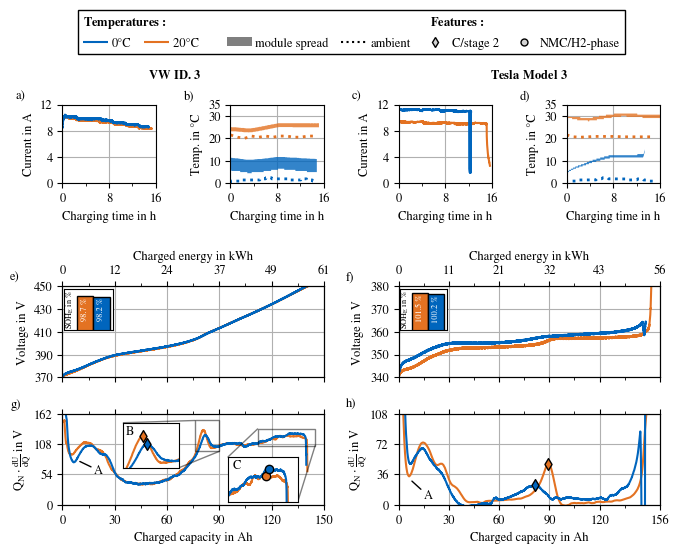

In [37]:
nrows = 2
heigth = 4.4 #cm
fig = plt.figure(figsize=(VisualizationConfig.textwidth_in_in.value+cm2inch(2.2),
                                3 * cm2inch(heigth)),constrained_layout=False)
gs = fig.add_gridspec(4, 4,hspace=0.5,height_ratios=[1.3, 0.5, 1.5, 1.5],wspace=0.8)
ax1 = fig.add_subplot(gs[0, 0])

ax2 = fig.add_subplot(gs[0,1])

ax3 = fig.add_subplot(gs[0,2])

ax4 = fig.add_subplot(gs[0,3])

ax5 = fig.add_subplot(gs[1,0:2])

ax6 = fig.add_subplot(gs[1,2:4])

ax7 = fig.add_subplot(gs[2,0:2])

ax8 = fig.add_subplot(gs[2,2:4])

ax9 = fig.add_subplot(gs[3,0:2])

ax10 = fig.add_subplot(gs[3,2:4])

# fill the axes
ax1 =  plot_current_vw(ax1, lst_dfs =  [df_vw_288_hot, df_vw_288_cold])
ax2 = plot_temp_vw(ax2, lst_dfs =  [df_vw_288_hot[::2000], df_vw_288_cold])


ax3 =  plot_current_tesla(ax3,lst_dfs =  [df_tesla_hot, df_tesla_cold])
ax4 = plot_temp_tesla(ax4, lst_dfs =  [df_tesla_hot, df_tesla_cold], lst_dfs_ambient_temp = [df_vw_288_hot[::2000], df_vw_288_cold]) # vehicles were placed next to each other, but the ambient temperature was not recorded with the Tesla

ax5.set_visible(False)
ax6.set_visible(False)

ax7 = plot_pOCV_vw(ax7, lst_dfs = [df_vw_288_hot, df_vw_288_cold])


ax8 = plot_pOCV_tesla(ax8, lst_dfs = [df_tesla_hot, df_tesla_cold])

ax9 = plot_dva_vw(ax9,
                     lst_cap = [cap_vw_288_hot, cap_vw_288_cold],
                     lst_dva = [dva_vw_288_hot, dva_vw_288_cold])

ax10 = plot_dva_tesla(ax10,
                            lst_cap = [cap_tesla_hot, cap_tesla_cold],
                            lst_dva = [dva_tesla_hot, dva_tesla_cold])

# legend
marker1 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker2 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
# legend
handles, labels =[],[]#ax1.get_legend_handles_labels()  
line1 = plt.hlines(0,0,1,label="0°C", color=colors[1])
line2 = plt.hlines(0,0,1,label="20°C     ", color=colors[0])
patch1 = mpatches.Patch(label="module spread", facecolor="k",alpha=0.5,edgecolor="none")
line5 = plt.hlines(0,0,1,label="ambient", color="k",linestyle=":")
lgd=fig.legend(handles=[line1,line2,patch1,line5,marker1,marker2],loc="center",fontsize=9,ncols=6,handletextpad=0.3,
            framealpha =1 , fancybox=False,columnspacing=1,edgecolor="black",bbox_to_anchor=(0.5,1.02),title=r"$\bf{Temperatures:}$"+"\t\t\t\t\t\t\t\t\t\t\t"+r"$\bf{Features:}$",alignment='left')
#plt.tight_layout()

ax1.text(-0.5, 1.1, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax1.transAxes)
ax2.text(-0.5, 1.1, 'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax2.transAxes)
ax3.text(-0.5, 1.1, 'c)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax3.transAxes)
ax4.text(-0.5, 1.1, 'd)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax4.transAxes)

ax7.text(-0.2, 1.1, 'e)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax7.transAxes)
ax8.text(-0.2, 1.1, 'f)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax8.transAxes)
ax9.text(-0.2, 1.1, 'g)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax9.transAxes)
ax10.text(-0.2, 1.1, 'h)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=ax10.transAxes)

fig.text(x=0.27, y = 0.93, s = r"$\bf{VW\ ID.3}$",fontsize=9,ha="center")
fig.text(x=0.73, y = 0.93, s = r"$\bf{Tesla\ Model\ 3}$",fontsize=9,ha="center")
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"03-FIG-Temperature.pdf"), bbox_inches='tight',bbox_extra_artists=(lgd,)) 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"03-FIG-Temperature.png"),dpi=300, pad_inches = 0) 

## assess H2

(0.0, 1.0)

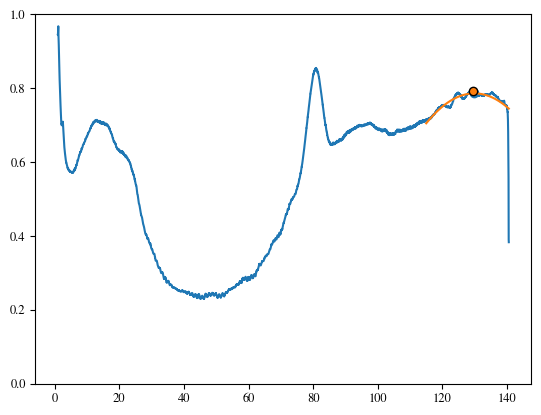

In [38]:
plt.plot(cap_vw_288_hot,dva_vw_288_hot)
Q,DVA = find_H2_peak(cap_vw_288_hot,dva_vw_288_hot,Q_min=115,Q_max=145)
plt.plot(Q,DVA)
maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA])
xpos, ypos = find_max_min(cap_vw_288_hot, dva_vw_288_hot, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="o",edgecolors="k",zorder=3)
plt.ylim(0,1)

(0.0, 1.0)

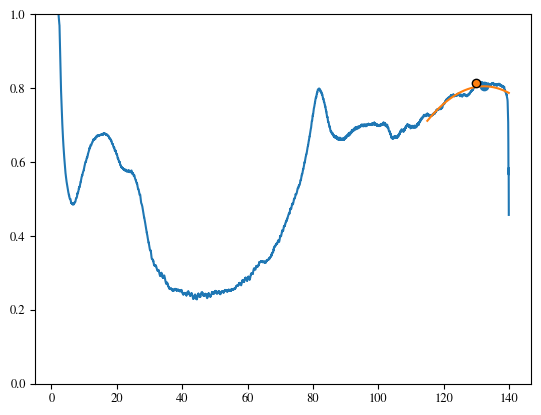

In [39]:
plt.plot(cap_vw_288_cold,dva_vw_288_cold)
Q,DVA = find_H2_peak(cap_vw_288_cold,dva_vw_288_cold,Q_min=115,Q_max=145)
plt.plot(Q,DVA)
maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA])
xpos, ypos = find_max_min(cap_vw_288_cold, dva_vw_288_cold, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="o",edgecolors="k",zorder=3)
plt.ylim(0,1)